In [1]:
import sys
sys.path.append("..")

In [2]:
import logging

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error

from config import BATCH_SIZE, MAX_K, small_dataset_path, medium_dataset_path, large_dataset_path
from src.dataset import create_train_val_datasets, GalacticBinariesDataset
from src.logger import setup_logging

setup_logging()

In [3]:
TRAIN_SAMPLES = None
VAL_SAMPLES = None
NOISE_TRAIN = True
NOISE_VAL = True
SEED_TRAIN = 42
SEED_VAL = 0

In [4]:
logger = logging.getLogger("EnergyBaseline")

In [5]:
train_dataset, val_dataset, val_energy_matched_dataset = create_train_val_datasets(
    dataset_path=medium_dataset_path,
    train_size=0.8,
    max_K=MAX_K,
    max_samples_train=TRAIN_SAMPLES,
    max_samples_val=VAL_SAMPLES,
    noise_train=NOISE_TRAIN,
    noise_val=NOISE_VAL,
    deterministic_train=False,
    deterministic_val=True,
    energy_matched_train=False,
    return_params=False,
    split_seed=SEED_TRAIN,
    seed_train=SEED_TRAIN,
    seed_val=SEED_VAL,
)

[05/28/26 12:14:04] INFO     Total waveforms in dataset: 500000

                    INFO     Selected 400000 waveforms for use in the dataset

                    INFO     Dataset length set to 400000 samples (max_samples=None)

                    INFO     Loading 400000 waveforms in memory...

[05/28/26 12:15:47] INFO     Waveforms loaded with shape (400000, 4, 128)

...

                    INFO     Dataset length set to 100000 samples (max_samples=None)

                    INFO     Loading 100000 waveforms in memory...

[05/28/26 12:16:53] INFO     Waveforms loaded with shape (100000, 4, 128)

                    INFO     Loading parameters amp, beta, f0, fddot, fdot, iota, lam, phi0, psi, snr in memory...

[05/28/26 12:16:55] INFO     Parameters loaded successfully

In [6]:
def collect_energy_and_labels(dataset: GalacticBinariesDataset) -> tuple[np.ndarray, np.ndarray]:
    energies = np.empty(len(dataset), dtype=np.float64)
    labels = np.empty(len(dataset), dtype=np.int64)

    for start in range(0, len(dataset), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(dataset))
        for i, dataset_idx in enumerate(range(start, end), start=start):
            waveform, target = dataset[dataset_idx]
            energies[i] = np.sum(np.asarray(waveform, dtype=np.float64) ** 2)
            labels[i] = target
    return energies, labels

In [7]:
train_energies, train_labels = collect_energy_and_labels(train_dataset)
val_energies, val_labels = collect_energy_and_labels(val_dataset)

In [8]:
def print_energy_stats(name: str, energies: np.ndarray, labels: np.ndarray) -> None:
    print(f"\n=== Energy stats: {name} ===")
    for k in range(1, MAX_K + 1):
        values = energies[labels == k]
        print(
            f"k={k:2d} | "
            f"mean={values.mean():.6g} | "
            f"std={values.std():.6g} | "
            f"p05={np.percentile(values, 5):.6g} | "
            f"p50={np.percentile(values, 50):.6g} | "
            f"p95={np.percentile(values, 95):.6g}"
        )

In [9]:
print_energy_stats("train", train_energies, train_labels)
print_energy_stats("val", val_energies, val_labels)


=== Energy stats: train ===
k= 1 | mean=3470.53 | std=2307.22 | p05=883.125 | p50=2869.2 | p95=8333.59
k= 2 | mean=6437.33 | std=3270.56 | p05=1979.61 | p50=5932.84 | p95=12451.8
k= 3 | mean=9362.08 | std=4023.8 | p05=3582.95 | p50=8904.93 | p95=16637.8
k= 4 | mean=12311.2 | std=4651.36 | p05=5465.4 | p50=11886.1 | p95=20664.6
k= 5 | mean=15239.1 | std=5206.56 | p05=7450.93 | p50=14801.3 | p95=24488.5
k= 6 | mean=18253.8 | std=5729.14 | p05=9595.16 | p50=17796.2 | p95=28346.2
k= 7 | mean=21215.3 | std=6220.46 | p05=11698.7 | p50=20794.1 | p95=32135.7
k= 8 | mean=24160.5 | std=6650.7 | p05=13969.3 | p50=23769.8 | p95=35800.2
k= 9 | mean=27093.3 | std=7127.39 | p05=16186.7 | p50=26622.3 | p95=39520.4
k=10 | mean=30070.8 | std=7464.68 | p05=18546.7 | p50=29646.7 | p95=43118.9

=== Energy stats: val ===
k= 1 | mean=3497.51 | std=2305.65 | p05=880.95 | p50=2920.76 | p95=8266.6
k= 2 | mean=6442.69 | std=3297.79 | p05=1951.75 | p50=5933.8 | p95=12526.3
k= 3 | mean=9381.46 | std=4013.27 | p05

In [14]:
def fit_mean_energy_baseline(energies: np.ndarray, labels: np.ndarray) -> dict[int, float]:
    return {
        k: float(energies[labels == k].mean())
        for k in range(1, MAX_K + 1)
    }


def predict_from_nearest_mean(energies: np.ndarray, mean_energy_by_k: dict[int, float]) -> np.ndarray:
    classes = np.array(sorted(mean_energy_by_k), dtype=np.int64)
    means = np.array([mean_energy_by_k[k] for k in classes], dtype=np.float64)
    closest_mean_indices = np.abs(energies[:, None] - means[None, :]).argmin(axis=1)
    return classes[closest_mean_indices]

In [15]:
mean_energy_by_k = fit_mean_energy_baseline(train_energies, train_labels)
val_predictions = predict_from_nearest_mean(val_energies, mean_energy_by_k)

print("\nMean train energy by k")
for k, mean_energy in mean_energy_by_k.items():
    print(f"k={k:2d}: {mean_energy:.6g}")

accuracy = accuracy_score(val_labels, val_predictions)
f1 = f1_score(val_labels, val_predictions, average="macro", zero_division=0)
mae = mean_absolute_error(val_labels, val_predictions)

print("\n=== Baseline total energy -> k ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"MAE:      {mae:.4f}")


Mean train energy by k
k= 1: 3470.53
k= 2: 6437.33
k= 3: 9362.08
k= 4: 12311.2
k= 5: 15239.1
k= 6: 18253.8
k= 7: 21215.3
k= 8: 24160.5
k= 9: 27093.3
k=10: 30070.8

=== Baseline total energy -> k ===
Accuracy: 0.3058
Macro F1: 0.2932
MAE:      1.1803


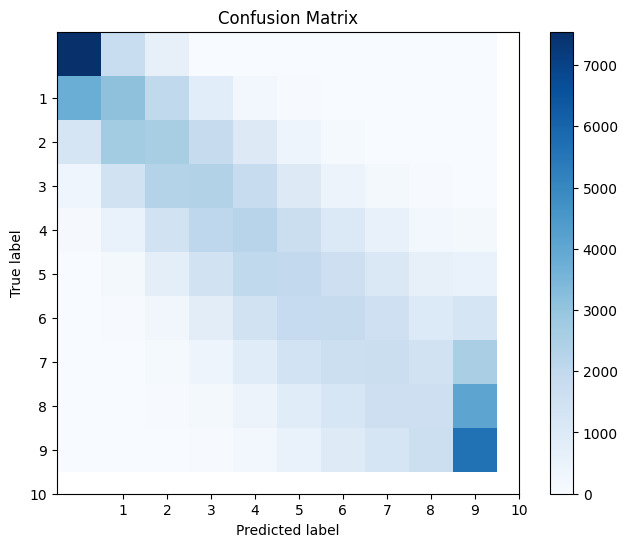

In [16]:
# plot confusion matrix
cm = confusion_matrix(val_labels, val_predictions, labels=range(1, MAX_K + 1))
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(1, MAX_K + 1)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [17]:
print(confusion_matrix(val_labels, val_predictions, labels=list(range(1, MAX_K + 1))))

[[7544 1750  617    0    0    0    0    0    0    0]
 [3797 3109 1995  805  213   42    4    1    0    0]
 [1291 2686 2585 1850  969  357   92   20    2    0]
 [ 346 1425 2304 2384 1790  988  440  154   45   16]
 [  71  527 1460 2082 2229 1663 1057  558  235  118]
 [   8  168  708 1433 1991 1962 1601 1068  590  517]
 [   1   45  250  786 1449 1862 1833 1573 1022 1273]
 [   0    4   90  354  861 1401 1636 1695 1457 2545]
 [   0    5   30  139  430  865 1233 1609 1601 4072]
 [   0    0    4   45  208  504  918 1252 1643 5638]]
